In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
a=pd.read_csv("student_dropout_dataset.csv")

In [16]:
a.head()

,age,gender,admission_grade,attendance_percentage,study_hours_per_day,scholarship,tuition_fees_paid,parents_education,family_income,exam_score,dropout_status
0,24,Male,100,93,2,Yes,Yes,Diploma,15152,45,1
1,18,Male,90,46,4,Yes,No,Bachelor,29727,84,1
2,22,Male,148,97,3,No,Yes,HighSchool,76278,77,0
3,21,Male,142,69,1,Yes,No,Master,88695,59,1
4,23,Male,120,73,4,Yes,No,Diploma,51806,45,1


In [62]:
a.columns

Index(['age', 'gender', 'admission_grade', 'attendance_percentage',
       'study_hours_per_day', 'scholarship', 'tuition_fees_paid',
       'parents_education', 'family_income', 'exam_score', 'dropout_status'],
      dtype='object')

In [63]:
a.tail()

,age,gender,admission_grade,attendance_percentage,study_hours_per_day,scholarship,tuition_fees_paid,parents_education,family_income,exam_score,dropout_status
995,22,Female,141,68,5,No,Yes,Bachelor,64325,84,0
996,19,Male,146,93,3,No,Yes,Master,88315,70,0
997,24,Female,112,42,2,Yes,Yes,HighSchool,23202,48,1
998,19,Male,105,92,4,Yes,Yes,Master,78310,63,0
999,19,Male,147,57,2,No,Yes,HighSchool,83958,75,1


In [10]:
a.isnull().sum()

age                      0
gender                   0
admission_grade          0
attendance_percentage    0
study_hours_per_day      0
scholarship              0
tuition_fees_paid        0
parents_education        0
family_income            0
exam_score               0
dropout_status           0
dtype: int64

In [64]:
a.duplicated().sum()


np.int64(0)

In [65]:
a[a.duplicated()]


,age,gender,admission_grade,attendance_percentage,study_hours_per_day,scholarship,tuition_fees_paid,parents_education,family_income,exam_score,dropout_status


In [17]:
a = a.drop("admission_grade", axis=1)

In [18]:
X = a.drop("dropout_status", axis=1)
y = a["dropout_status"]

In [19]:
a.shape

(1000, 10)

In [20]:
a.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    1000 non-null   int64 
 1   gender                 1000 non-null   object
 2   attendance_percentage  1000 non-null   int64 
 3   study_hours_per_day    1000 non-null   int64 
 4   scholarship            1000 non-null   object
 5   tuition_fees_paid      1000 non-null   object
 6   parents_education      1000 non-null   object
 7   family_income          1000 non-null   int64 
 8   exam_score             1000 non-null   int64 
 9   dropout_status         1000 non-null   int64 
dtypes: int64(6), object(4)
memory usage: 78.3+ KB


In [21]:
a.describe()


,age,attendance_percentage,study_hours_per_day,family_income,exam_score,dropout_status
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,20.943000,69.073000,3.093000,53659.312000,69.828000,0.78400
std,1.986378,17.493247,1.379222,26068.308623,17.468072,0.41172
min,18.000000,40.000000,1.000000,10097.000000,40.000000,0.00000
25%,19.000000,54.000000,2.000000,30632.250000,55.000000,1.00000
50%,21.000000,68.000000,3.000000,53178.000000,69.000000,1.00000
75%,23.000000,85.000000,4.000000,77130.750000,86.000000,1.00000
max,24.000000,99.000000,5.000000,99922.000000,99.000000,1.00000


In [22]:
categorical_features = ['gender', 'parents_education']
numerical_features = X.drop(columns=categorical_features).columns

In [9]:
a['dropout_status'].value_counts()


dropout_status
1    784
0    216
Name: count, dtype: int64

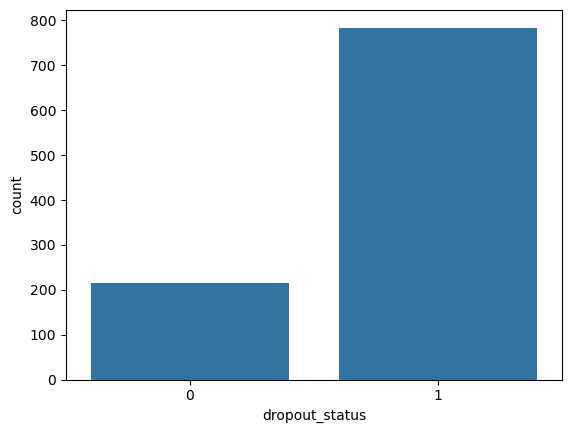

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='dropout_status', data=a)
plt.show()


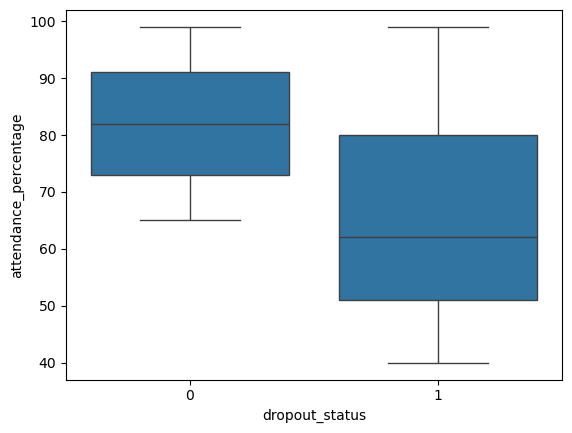

In [12]:
sns.boxplot(x='dropout_status', y='attendance_percentage', data=a)
plt.show()


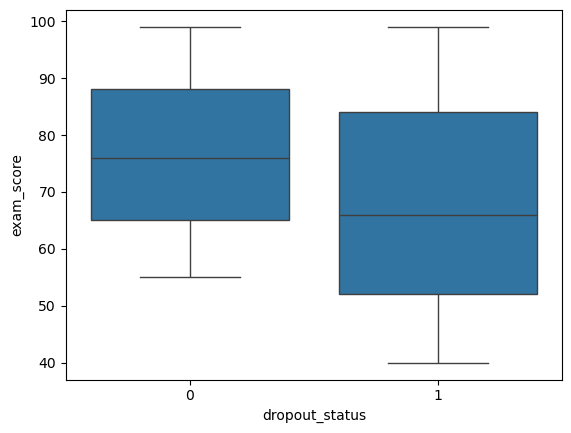

In [25]:
sns.boxplot(x='dropout_status', y='exam_score', data=a)
plt.show()


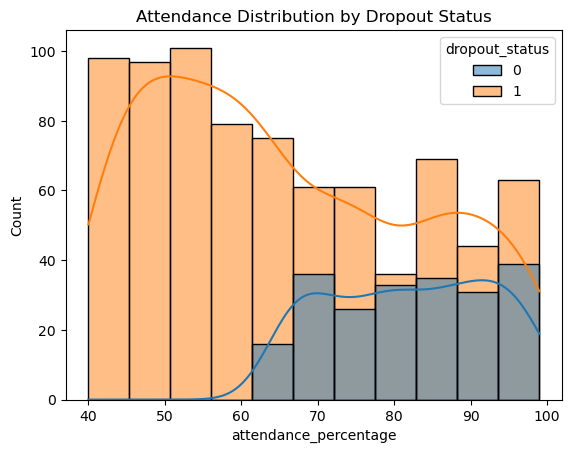

In [26]:
sns.histplot(data=a, x="attendance_percentage", hue="dropout_status", kde=True)
plt.title("Attendance Distribution by Dropout Status")
plt.show()


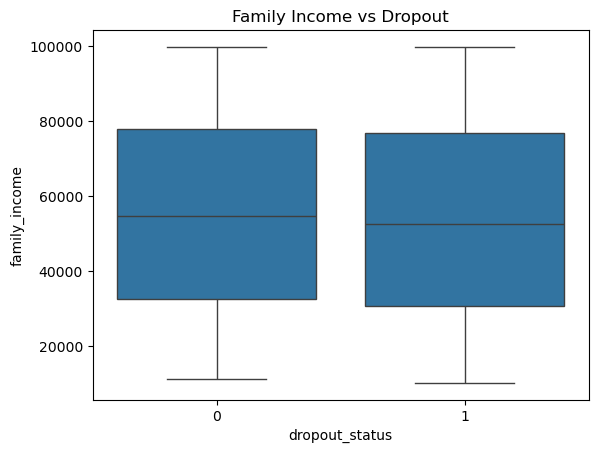

In [27]:
sns.boxplot(x='dropout_status', y='family_income', data=a)
plt.title("Family Income vs Dropout")
plt.show()


In [28]:
print(X.columns)

Index(['age', 'gender', 'attendance_percentage', 'study_hours_per_day',
       'scholarship', 'tuition_fees_paid', 'parents_education',
       'family_income', 'exam_score'],
      dtype='object')


In [55]:
categorical_features = [
    'gender',
    'parents_education',
    'scholarship',
    'tuition_fees_paid'
]
numerical_features = X.drop(columns=categorical_features).columns

In [76]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [77]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [79]:
from sklearn.pipeline import Pipeline

In [80]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
])

In [81]:
log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)

In [84]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

In [85]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.995
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        48
           1       0.99      1.00      1.00       152

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200



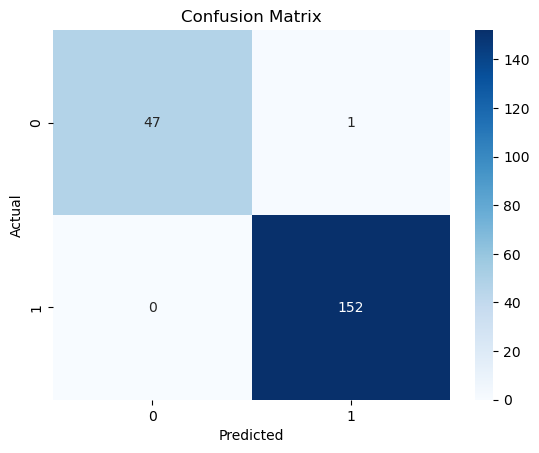

In [86]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [87]:
model = pipeline.named_steps['model']

importances = model.feature_importances_

feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

                              Feature  Importance
5          cat__tuition_fees_paid_Yes    0.385084
7          num__attendance_percentage    0.323683
10                    num__exam_score    0.178077
9                  num__family_income    0.046388
6                            num__age    0.022034
8            num__study_hours_per_day    0.016246
4                cat__scholarship_Yes    0.007429
0                    cat__gender_Male    0.006096
3       cat__parents_education_Master    0.005541
2   cat__parents_education_HighSchool    0.005085
1      cat__parents_education_Diploma    0.004337


In [89]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_acc, rf_acc]
})

print(results)

                 Model  Accuracy
0  Logistic Regression     0.890
1        Random Forest     0.995


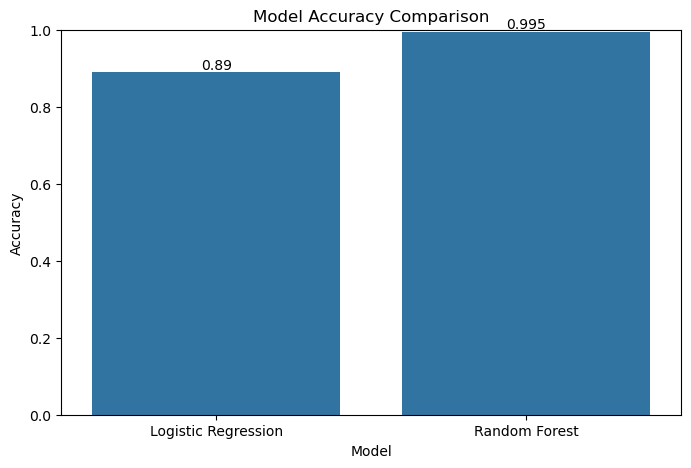

In [90]:
plt.figure(figsize=(8,5))

ax = sns.barplot(x="Model", y="Accuracy", data=results)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Model Accuracy Comparison")
plt.ylim(0,1)

plt.show()

In [91]:
import joblib
joblib.dump(rf_model, "student_dropout_model.pkl")

['student_dropout_model.pkl']

In [92]:
print(a['parents_education'].unique())

['Diploma' 'Bachelor' 'HighSchool' 'Master']
